# Middleware in LangChain

## Context

[LangChain](https://docs.langchain.com/) aims to make it easy to build LLM applications. One type of LLM application you can build is an agent. Agents are exciting because they can automate a wide range of tasks that were previously impossible. 

In practice though, it is incredibly difficult to build systems that reliably execute on these tasks as more control is often necessary. You might need an agent to always call a specific tool first or use different prompts based on its state. 

You can acheive this control through implementing middleware, which we're going to learn about today through building an agent in [LangGraph](https://docs.langchain.com/oss/python/langgraph/overview), a framework for building agent and multi-agent applications that lives on top of LangChain. 

## Goals

This module walks through the core agent loop and why middleware matters.

First, you'll build your own AI agent.

Then you'll add middleware for more control.

You'll also add some custom middleware for even more speciifc use cases.

Finally, you'll run the agents in LangGraph Studio so you can inspect what the traces the agent produces.

Let's get started with the core agent loop.

In [21]:
%%capture --no-stderr
%pip install --quiet -U langchain langchain-core langchain-openai langgraph langchain-community wikipedia python-dotenv rich



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## The Core Agent Loop

The core agent loop involves calling a model, letting it choose which [tool](https://docs.langchain.com/oss/python/langchain/tools) to execute, and finishing the loop when it calls no more tools.

This pattern is called the [ReAct](https://docs.langchain.com/oss/python/langchain/agents) loop, a general agent architecture.

- `act` - let the model call specific tools
- `observe` - pass the tool output back to the model
- `reason` - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

This loop is useful because the same agent structure works whether the tools search data, call APIs, update records, or perform calculations.

# ![Core Agent Loop](assets/core_agent_loop.avif)

## Middleware

[Middleware](https://docs.langchain.com/oss/python/langchain/middleware/overview) exposes hooks right before and after each one of these steps.

# ![Middleware](assets/middleware_final.avif)

A hook is a point in the agent loop where you can plug in your own code.

Hooks can run at any of these points: 
- **before_agent / after_agent** - once per agent invocation
- **before_model / after_model** - around each model call inside the loop
- **wrap_model_call** - wraps the model call itself
- **wrap_tool_call** - wraps each tool execution

Use middleware when your flow is more than the basic “call the model, run tools, repeat until done” loop.

## Middleware Use Cases

Middleware lets you add behavior around the agent loop without rewriting the agent itself. In this module, we'll focus on four practical patterns:

### 1. Human approval

Some actions should pause before they run. For example, a refund agent can ask for approval before issuing a refund.

This is useful for actions that are expensive, irreversible, sensitive, or require a reviewer.

### 2. Custom tool gating

Sometimes the approval rule is more specific than "always pause before this tool." For example, only refunds over $100 should require approval.

Custom middleware lets you inspect the tool call, apply application logic, and decide whether to continue, interrupt, or reject the action.

### 3. Task planning

Some user requests have multiple steps. For example, a trip planning agent needs to check weather, build a packing list, and suggest an activity.

Todo list middleware gives the agent a planning tool so the trace shows how it breaks the task down and completes each step.

### 4. Conversation summarization

Long-running agents collect a lot of context. For example, a research agent may gather information from several Wikipedia pages before writing a final answer.

Summarization middleware compresses older messages while keeping recent messages available, so the agent can continue with the important context preserved.

We'll also view these agents in LangGraph Studio so you can inspect messages, tool calls, interrupts, state, and traces.


## Picking a Middleware

LangChain ships a library of built-in middlewares for common needs. A few examples from the [full list](https://docs.langchain.com/oss/python/langchain/middleware/built-in):

- `HumanInTheLoopMiddleware`: pause execution so a human can approve, edit, or reject a tool call before it runs.
- `TodoListMiddleware`: give the agent a todo list tool so it can plan multi-step tasks, track progress, and complete each step in order.
- `SummarizationMiddleware`: compress old conversation history when the context window fills up.




## Let's Build an Agent

First, pass in your API keys here. You can decide to use a different model provider if you like, but this module has been configured for OpenAI.

In [14]:
import getpass
import os

from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OPENAI_API_KEY: ")

In [15]:
if not os.environ.get("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass("LANGSMITH_API_KEY: ")

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy-middleware"

### Refund Agent With Tools

Lets create a customer refund support agent with `create_agent()`:

1. Read the conversation so far.
2. Call the model to decide the next step.
3. If the model asks for a tool, run that tool.
4. Add the tool result back into the conversation.
5. Repeat until the model gives a final answer.


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I'd like a refund on order A100. It arrived damaged.                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: lookup_order                                                                                      │
│    Args: {                                                                                                      │
│   "order_id": "A100"                                                                                            │
│ }                                                                                                               │
│    ID: call_GAtEA5eGM2JL1T7JUW94Rpjg                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ delivered, total $45.00                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: issue_refund                                                                                      │
│    Args: {                                                                                                      │
│   "order_id": "A100",                                                                                           │
│   "reason": "Arrived damaged"                                                                                   │
│ }                                                                                                               │
│    ID: call_5SuVNzQR1uw7X5kjYJvhLVng                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Refund processed for order A100. Reason: Arrived damaged                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Your refund for order A100 has been processed due to damage upon arrival. The total amount of $45.00 will be    │
│ credited back to your original payment method. If you have any further questions or concerns, feel free to ask! │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

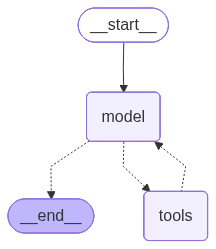

In [7]:
from langchain.agents import create_agent
from langchain_core.tools import tool
from IPython.display import Image, display
from utils import format_messages


@tool
def lookup_order(order_id: str) -> str:
    """Look up a customer's order by ID."""
    orders = {
        "A100": "delivered, total $45.00",
        "B200": "delivered, total $120.00",
    }
    return orders.get(order_id, "order not found")


@tool
def issue_refund(order_id: str, reason: str) -> str:
    """Issue a refund for a customer's order."""
    return f"Refund processed for order {order_id}. Reason: {reason}"


refund_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[lookup_order, issue_refund],
    system_prompt="You are a customer refund support agent. Look up the order and issue a refund when a customer requests one.",
)

result = refund_agent.invoke(
    {"messages": [{"role": "user", "content": "I'd like a refund on order A100. It arrived damaged."}]}
)

format_messages(result["messages"])

display(Image(refund_agent.get_graph(xray=True).draw_mermaid_png()))


### What just happened, and what's missing

The agent looked up order A100, decided $45 was the right refund amount, issued the refund, and replied. All on its own, with no human in the loop.

The problem in production though is there's no checkpoint where a person can step in. If the model hallucinates the amount, picks the wrong order, or gets talked into refunding something it shouldn't, the refund still fires.

This is what middleware solves. The rest of the notebook adds will add guardrails to different agents.


## Refund Agent With Built-In HITL Middleware

For our refund agent, `HumanInTheLoopMiddleware`(HITL) is the right pick.

Looking up order information is not a high stakes action. The agent should freely be able to find the info on the order as needed.

Refunds though are a high-stakes action. We don't want the agent issuing one without a human signing off.

HITL pauses the loop right before `issue_refund` fires, surfaces the proposed call to a person, and only proceeds once they approve.

In [16]:
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import MemorySaver # in-memory state snapshots; required so interrupt() can pause and continue
from langgraph.types import Command
from IPython.display import Image, display
from utils import format_messages

refund_agent_with_hitl = create_agent(
    model="openai:gpt-4o-mini",
    tools=[lookup_order, issue_refund],
    system_prompt="You are a customer refund support agent. Look up the order and issue a refund when a customer requests one.",
    checkpointer=MemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "issue_refund": {"allowed_decisions": ["approve", "edit", "reject"]},
            }
        )
    ],
)

config = {"configurable": {"thread_id": "refund-session-1"}}

result = refund_agent_with_hitl.invoke(
    {"messages": [{"role": "user", "content": "I'd like a refund on order A100. It arrived damaged."}]},
    config=config,
)

if "__interrupt__" in result:
    print("Pending action:")
    print(result["__interrupt__"])

    decision = input("Approve this refund? (y/n): ").strip().lower()

    if decision == "y":
        result = refund_agent_with_hitl.invoke(
            Command(resume={"decisions": [{"type": "approve"}]}),
            config=config,
        )
    else:
        result = refund_agent_with_hitl.invoke(
            Command(resume={"decisions": [{"type": "reject", "feedback": "Rejected by reviewer"}]}),
            config=config,
        )

format_messages(result["messages"])

display(Image(refund_agent_with_hitl.get_graph(xray=True).draw_mermaid_png()))


Pending action:
[Interrupt(value={'action_requests': [{'name': 'issue_refund', 'args': {'order_id': 'A100', 'reason': 'Item arrived damaged.'}, 'description': "Tool execution requires approval\n\nTool: issue_refund\nArgs: {'order_id': 'A100', 'reason': 'Item arrived damaged.'}"}], 'review_configs': [{'action_name': 'issue_refund', 'allowed_decisions': ['approve', 'edit', 'reject']}]}, id='f26382fd1dd5c6870eba841909528839')]


KeyboardInterrupt: Interrupted by user

### Retrospective

- The built-in HITL middleware paused before the refund tool ran, so a reviewer could approve or reject the action.
- The formatted messages make it easier to see what happened before and after the approval step.
- To view this flow in LangGraph Studio, expose the agent from a Python file and run `langgraph dev`. Studio will let you inspect the run, state, tool calls, and interrupt/resume behavior.


## Refund Agent With Custom HITL Middleware

Built-in HITL pauses on every refund. In practice, that's a little blunt.

Most refunds are small and routine. Only the high-dollar ones need human eyes.

`wrap_tool_call` lets us write a custom gate. It checks the proposed refund amount, pauses only when it exceeds $100, and lets smaller refunds flow through automatically.


In [17]:
from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver # in-memory state snapshots; required so interrupt() can pause and continue
from langgraph.types import Command, interrupt
from utils import format_messages

@tool
def lookup_order(order_id: str) -> str:
    """Look up a customer's order by ID."""
    orders = {
        "A100": "delivered, total $45.00",
        "B200": "delivered, total $120.00",
    }
    return orders.get(order_id, "order not found")

@tool
def issue_refund(order_id: str, amount: float, reason: str) -> str:
    """Issue a refund for a customer's order."""
    return f"Refund of ${amount:.2f} processed for order {order_id}. Reason: {reason}"

@wrap_tool_call
def refund_threshold_gate(request, handler):
    """Pause for human approval only when the refund amount exceeds $100."""
    if request.tool_call["name"] == "issue_refund":
        amount = request.tool_call["args"].get("amount", 0)

        print(f"\nMiddleware saw refund request for ${amount:.2f}")

        if amount > 100:
            print("Middleware paused execution for approval.")

            decision = interrupt({
                "action": "issue_refund",
                "args": request.tool_call["args"],
                "message": f"Refund of ${amount:.2f} exceeds the $100 threshold. Approve?",
            })

            if not decision.get("approved", False):
                print("Middleware rejected the refund.")

                return ToolMessage(
                    content="Refund rejected by reviewer.",
                    tool_call_id=request.tool_call["id"],
                )

            print("Middleware approved the refund.")

    return handler(request)

gated_refund_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[lookup_order, issue_refund],
    system_prompt=(
        "You are a customer refund support agent. "
        "Look up the order to get the total, then issue a refund for that amount."
    ),
    checkpointer=MemorySaver(),
    middleware=[refund_threshold_gate],
)

config = {"configurable": {"thread_id": "threshold-session-1"}}

result = gated_refund_agent.invoke(
    {"messages": [{"role": "user", "content": "I'd like a refund on order B200. It arrived damaged."}]},
    config=config,
)

if "__interrupt__" in result:
    print("Pending action (over $100 threshold):")
    print(result["__interrupt__"])

    decision = input("Approve this refund? (y/n): ").strip().lower()

    result = gated_refund_agent.invoke(
        Command(resume={"approved": decision == "y"}),
        config=config,
    )

format_messages(result["messages"])

display(Image(gated_refund_agent.get_graph(xray=True).draw_mermaid_png()))



Middleware saw refund request for $120.00
Middleware paused execution for approval.
Pending action (over $100 threshold):
[Interrupt(value={'action': 'issue_refund', 'args': {'order_id': 'B200', 'amount': 120, 'reason': 'Arrived damaged'}, 'message': 'Refund of $120.00 exceeds the $100 threshold. Approve?'}, id='08b21a807bf8b922001bd38f4f81f5db')]


KeyboardInterrupt: Interrupted by user

### Refund Agent With Custom HITL Middleware Retrospective

- The custom middleware checked the refund amount before allowing the tool call to continue.
- The graph still shows a normal `tools` node because middleware runs inside tool execution rather than as a separate graph node.
- To debug this more deeply, use `langgraph dev` with the agent exposed in `langgraph.json`. That gives you an interactive view of the run even though custom middleware will still appear as behavior inside the tool step.


## Trip Planning Agent With Todo List Middleware

Trip planning has several small steps: check the weather, build a packing list, and suggest an activity.

`TodoListMiddleware` gives the agent a todo list tool so it can plan the task, track progress, and complete each step in order.

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I'm taking a 3-day work trip to Seattle. Help me check the weather, make a packing list, and suggest one        │
│ evening activity.                                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: get_weather                                                                                       │
│    Args: {                                                                                                      │
│   "city": "Seattle"                                                                                             │
│ }                                                                                                               │
│    ID: call_cu5P9AaQN6QLFrGxxNNZ2eY4                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Cool and rainy, around 52°F. Bring a rain jacket.                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: make_packing_list                                                                                 │
│    Args: {                                                                                                      │
│   "city": "Seattle",                                                                                            │
│   "days": 3,                                                                                                    │
│   "trip_type": "work"                                                                                           │
│ }                                                                                                               │
│    ID: call_AclK0bUZ8bRy1U6gaxuQHUjC                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Packing list for a 3-day work trip to Seattle: rain jacket, comfortable shoes, laptop, charger, toiletries, two │
│ work outfits, casual evening clothes, and travel documents.                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: suggest_activity                                                                                  │
│    Args: {                                                                                                      │
│   "city": "Seattle",                                                                                            │
│   "time_of_day": "evening"                                                                                      │
│ }                                                                                                               │
│    ID: call_I2LWt5Q8QDEGAgNKSrPdISJn                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Visit Pike Place Market and get dinner near the waterfront.                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Here's your trip plan for Seattle:                                                                              │
│                                                                                                                 │
│ **Weather**: Cool and rainy, around 52°F. Bring a rain jacket.                                                  │
│                                                                                                                 │
│ **Packing List**:                                                                                               │
│ - Rain jacket                                                                                                   │
│ - Comfortable shoes                                                                                             │
│ - Laptop and charger                                                                                            │
│ - Toiletries                                                                                                    │
│ - Two work outfits                                                                                              │
│ - Casual evening clothes                                                                                        │
│ - Travel documents                                                                                              │
│                                                                                                                 │
│ **Evening Activity**: Visit Pike Place Market and enjoy dinner near the waterfront. Have a great trip!          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

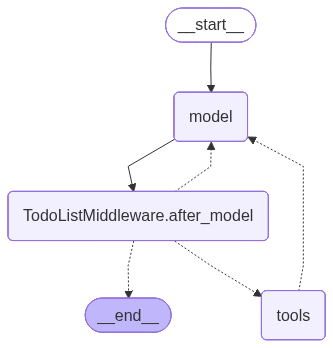

In [18]:
from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import TodoListMiddleware
from langchain_core.tools import tool
from utils import format_messages


@tool
def get_weather(city: str) -> str:
    """Get a simple weather forecast for a city."""
    forecasts = {
        "Seattle": "Cool and rainy, around 52°F. Bring a rain jacket.",
        "Austin": "Warm and sunny, around 78°F. Bring light clothing.",
        "New York": "Mild and breezy, around 60°F. Bring layers.",
    }

    return forecasts.get(city, f"No forecast found for {city}.")


@tool
def make_packing_list(city: str, days: int, trip_type: str) -> str:
    """Create a packing list for a trip."""
    return (
        f"Packing list for a {days}-day {trip_type} trip to {city}: "
        "rain jacket, comfortable shoes, laptop, charger, toiletries, "
        "two work outfits, casual evening clothes, and travel documents."
    )


@tool
def suggest_activity(city: str, time_of_day: str) -> str:
    """Suggest one activity for a city."""
    activities = {
        "Seattle": "Visit Pike Place Market and get dinner near the waterfront.",
        "Austin": "Walk around South Congress and listen to live music.",
        "New York": "Visit the High Line and grab dinner nearby.",
    }

    return activities.get(city, f"No activity suggestion found for {city}.")


trip_planning_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[
        get_weather,
        make_packing_list,
        suggest_activity,
    ],
    system_prompt=(
        "You are a concise trip planning assistant. "
        "For multi-step trip requests, create a short todo list first. "
        "Then complete each step: check the weather, make a packing list, "
        "and suggest one activity. Keep the final answer brief."
    ),
    middleware=[
        TodoListMiddleware(),
    ],
)


result = trip_planning_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "I'm taking a 3-day work trip to Seattle. "
                    "Help me check the weather, make a packing list, "
                    "and suggest one evening activity."
                ),
            }
        ]
    }
)


format_messages(result["messages"])

display(Image(trip_planning_agent.get_graph(xray=True).draw_mermaid_png()))


### Trip Planning Agent With Todo List Middleware

- The todo middleware gave the agent a `write_todos` tool so it could plan the trip request before completing the steps.
- This is useful for multi-step tasks because the trace shows the agent planning, calling tools, and producing the final answer.
- To inspect the todo tool calls in LangGraph Studio, move this agent into a Python module and run `langgraph dev`. Studio is the best place to view the full run trace and tool call sequence.


## Research Agent With Summarization Middleware

Research agents often collect facts across multiple turns.

`SummarizationMiddleware` compresses older research notes as the conversation grows, while keeping recent messages available. This helps the agent combine information from different topics into one final answer.

In [20]:
from IPython.display import Image, display

from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_community.document_loaders import WikipediaLoader
from langgraph.checkpoint.memory import InMemorySaver
from utils import format_messages


@tool
def fetch_wikipedia_summary(topic: str) -> str:
    """Fetch a short summary from Wikipedia for a topic."""
    docs = WikipediaLoader(
        query=topic,
        load_max_docs=1,
        doc_content_chars_max=1200,
    ).load()

    if not docs:
        return f"No Wikipedia results found for {topic}."

    page = docs[0]
    title = page.metadata.get("title", topic)
    source = page.metadata.get("source", "Wikipedia")

    return f"Title: {title}\nSource: {source}\n\n{page.page_content}"


research_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[fetch_wikipedia_summary],
    system_prompt=(
        "You are a concise research assistant. "
        "Use Wikipedia to gather facts across the conversation. "
        "When asked for a final answer, combine the important facts into a short, clear summary."
    ),
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="openai:gpt-4o-mini",
            # Demo setting: summarize quickly after only a few messages.
            trigger=("messages", 3),
            # Keep the latest messages unchanged.
            keep=("messages", 2),
        ),
    ],
)


config = {"configurable": {"thread_id": "ai-history-wikipedia-demo"}}

conversation_turns = [
    "Look up Ada Lovelace on Wikipedia.",
    "Now look up Alan Turing on Wikipedia.",
    "Now look up Andrej Karpathy on Wikipedia.",
    "Using everything so far, summarize the path from early computing to modern AI.",
]

for user_message in conversation_turns:
    result = research_agent.invoke(
        {"messages": [{"role": "user", "content": user_message}]},
        config=config,
    )


format_messages(result["messages"])

display(Image(research_agent.get_graph(xray=True).draw_mermaid_png()))


KeyboardInterrupt: 

### Research Agent With Summarization Middleware Retrospective

- The summarization middleware compressed older research context while keeping recent messages available.
- This helps the agent combine information from several Wikipedia lookups without carrying the full conversation forever.
- To view the summarized state and tool calls interactively, expose this research agent in `langgraph.json` and run `langgraph dev`. For hosted/persistent traces across runs, enable LangSmith tracing with `LANGSMITH_TRACING=true` and `LANGSMITH_API_KEY`.


## LangGraph Studio

- Run the examples in `module-1/studio` with `langgraph dev` to inspect each agent in LangGraph Studio.
- Studio lets you view messages, tool calls, interrupts, state, and traces for each middleware example.
- These examples use LangChain middleware with `create_agent`, which is the simplest way to add behavior around an agent loop.

## Next Steps: Deep Agents

Deep Agents are a more advanced pattern for custom long-running agents with planning, memory, file systems, and subagents. If you want to build your own more capable agent architecture, Deep Agents are the next layer to explore after these middleware examples.
